In [2]:
import pandas as pd
import numpy as np

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [4]:
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

import warnings
warnings.filterwarnings('ignore')

print(' Libraries loaded successfully.')

 Libraries loaded successfully.


In [6]:
df = pd.read_csv('../data/IPL.csv')

print(f' Shape      : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f' Columns    : {list(df.columns)}')
print()
df.head()

 Shape      : 278,205 rows × 64 columns
 Columns    : ['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']



,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,ball_no,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,runs_total,runs_bowler,runs_not_boundary,extra_type,non_striker,non_striker_pos,wicket_kind,...,city,day,month,year,season,gender,team_type,superover_winner,result_type,method,balls_per_over,overs,event_match_no,stage,match_number,team_runs,team_balls,team_wicket,new_batter,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,131970,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0.10,SC Ganguly,1,0,1,P Kumar,1,1,1,0,False,legbyes,BB McCullum,2,NaN,...,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,1,1,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,131971,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0.20,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,...,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,1,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,131972,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.30,BB McCullum,2,0,0,P Kumar,0,1,1,1,False,wides,SC Ganguly,1,NaN,...,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,2,0,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,131973,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.30,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,...,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,3,0,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,131974,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0.40,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,...,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,4,0,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [ ]:
print(' Data Types:\n')
print(df.dtypes)

In [ ]:
df.describe(include='all')

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_report)}')
print()
print(missing_report)

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(0)


object_cols = df.select_dtypes(include='object').columns
df[object_cols] = df[object_cols].fillna('Unknown')

print(f' Missing values after cleaning: {df.isnull().sum().sum()}')

In [7]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['season'] = df['date'].dt.year
    print(f' Seasons found: {sorted(df["season"].dropna().unique().astype(int))}')


for col in ['runs_batter', 'extras', 'runs_off_bat']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print('\n Data types fixed.')

 Seasons found: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

 Data types fixed.


In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
after = len(df)

print(f'Rows before: {before:,} | Rows after: {after:,} | Removed: {before - after:,}')

Rows before: 278,205 | Rows after: 278,205 | Removed: 0


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
    Total Matches  : 1,169
    Total Deliveries: 278,205
    Total Seasons  : 18
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━


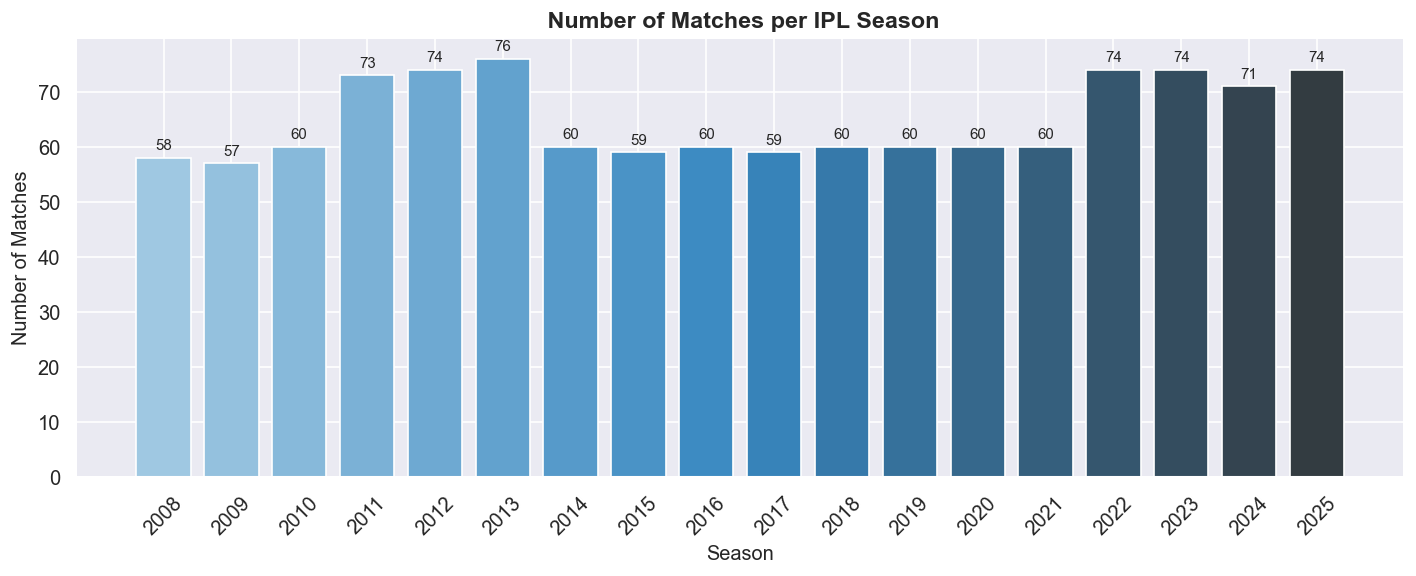

In [27]:

total_matches = df['match_id'].nunique()
total_balls   = len(df)
total_seasons = df['season'].nunique() if 'season' in df.columns else 'N/A'

print('━' * 40)
print(f'    Total Matches  : {total_matches:,}')
print(f'    Total Deliveries: {total_balls:,}')
print(f'    Total Seasons  : {total_seasons}')
print('━' * 40)


if 'season' in df.columns:
    matches_per_season = df.groupby('season')['match_id'].nunique().reset_index()
    matches_per_season.columns = ['Season', 'Matches']

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(matches_per_season['Season'].astype(str),
                  matches_per_season['Matches'],
                  color=sns.color_palette('Blues_d', len(matches_per_season)))
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(' Number of Matches per IPL Season', fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Number of Matches')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

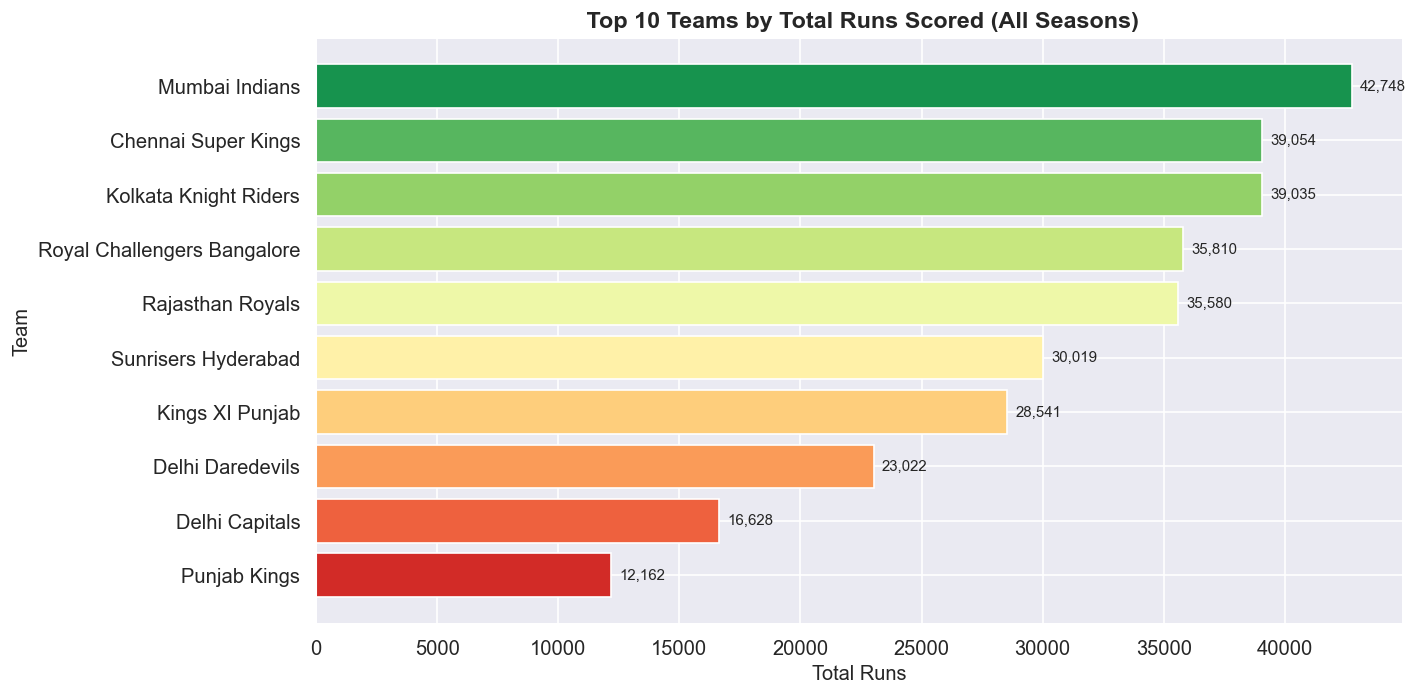

               batting_team  Total Runs
             Mumbai Indians       42748
        Chennai Super Kings       39054
      Kolkata Knight Riders       39035
Royal Challengers Bangalore       35810
           Rajasthan Royals       35580
        Sunrisers Hyderabad       30019
            Kings XI Punjab       28541
           Delhi Daredevils       23022
             Delhi Capitals       16628
               Punjab Kings       12162


In [11]:

runs_col = 'runs_batter' if 'runs_batter' in df.columns else 'runs_off_bat'

team_runs = (
    df.groupby('batting_team')[runs_col]
    .sum()
    .reset_index()
    .rename(columns={runs_col: 'Total Runs'})
    .sort_values('Total Runs', ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(12, 6))
palette = sns.color_palette('RdYlGn', len(team_runs))
bars = ax.barh(team_runs['batting_team'], team_runs['Total Runs'], color=palette[::-1])
ax.bar_label(bars, fmt='{:,.0f}', padding=5, fontsize=9)
ax.set_title(' Top 10 Teams by Total Runs Scored (All Seasons)', fontweight='bold')
ax.set_xlabel('Total Runs')
ax.set_ylabel('Team')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(team_runs.to_string(index=False))

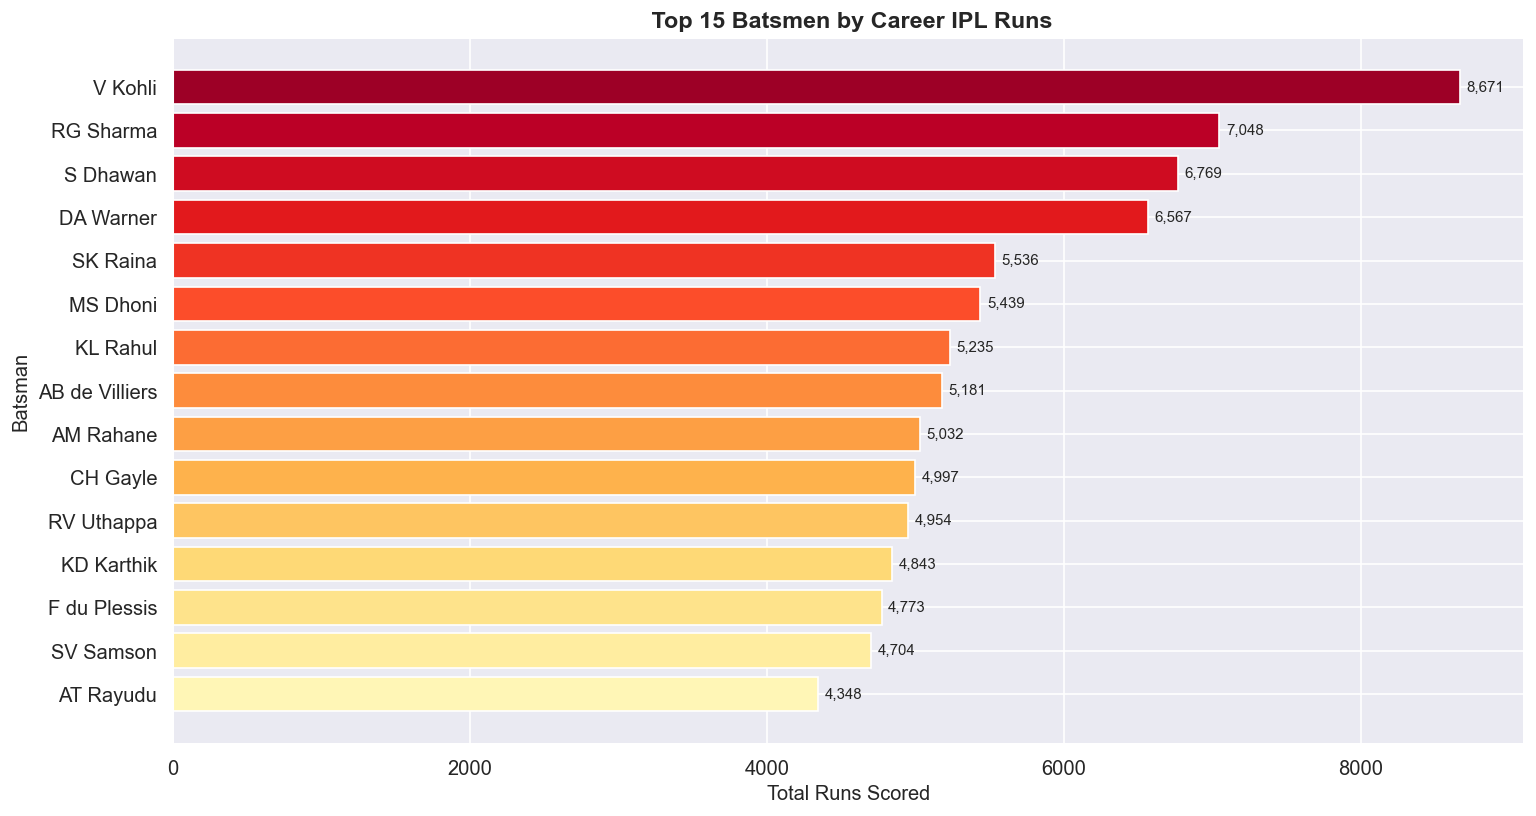

        batter  Total Runs
       V Kohli        8671
     RG Sharma        7048
      S Dhawan        6769
     DA Warner        6567
      SK Raina        5536
      MS Dhoni        5439
      KL Rahul        5235
AB de Villiers        5181
     AM Rahane        5032
      CH Gayle        4997
    RV Uthappa        4954
    KD Karthik        4843
  F du Plessis        4773
     SV Samson        4704
     AT Rayudu        4348


In [12]:

runs_col = 'runs_batter' if 'runs_batter' in df.columns else 'runs_off_bat'

top_batsmen = (
    df.groupby('batter')[runs_col]
    .sum()
    .reset_index()
    .rename(columns={runs_col: 'Total Runs'})
    .sort_values('Total Runs', ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette('YlOrRd', len(top_batsmen))[::-1]
bars = ax.barh(top_batsmen['batter'], top_batsmen['Total Runs'], color=palette)
ax.bar_label(bars, fmt='{:,.0f}', padding=4, fontsize=9)
ax.set_title(' Top 15 Batsmen by Career IPL Runs', fontweight='bold')
ax.set_xlabel('Total Runs Scored')
ax.set_ylabel('Batsman')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(top_batsmen.to_string(index=False))

In [13]:


wicket_col = None
for col in ['player_dismissed', 'wicket_type', 'is_wicket']:
    if col in df.columns:
        wicket_col = col
        break

if wicket_col:

    if df[wicket_col].dtype == object:
        wicket_df = df[df[wicket_col].notna() & (df[wicket_col] != '') & (df[wicket_col] != 'Unknown')]
    else:
        wicket_df = df[df[wicket_col] == 1]

    top_bowlers = (
        wicket_df.groupby('bowler')
        .size()
        .reset_index(name='Wickets')
        .sort_values('Wickets', ascending=False)
        .head(15)
    )

    fig, ax = plt.subplots(figsize=(13, 7))
    palette = sns.color_palette('Blues_r', len(top_bowlers))
    bars = ax.barh(top_bowlers['bowler'], top_bowlers['Wickets'], color=palette)
    ax.bar_label(bars, padding=4, fontsize=9)
    ax.set_title(' Top 15 Bowlers by Career IPL Wickets', fontweight='bold')
    ax.set_xlabel('Total Wickets')
    ax.set_ylabel('Bowler')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.show()
    print(top_bowlers.to_string(index=False))
else:
    print('  No wicket column detected. Please check column names.')

  No wicket column detected. Please check column names.


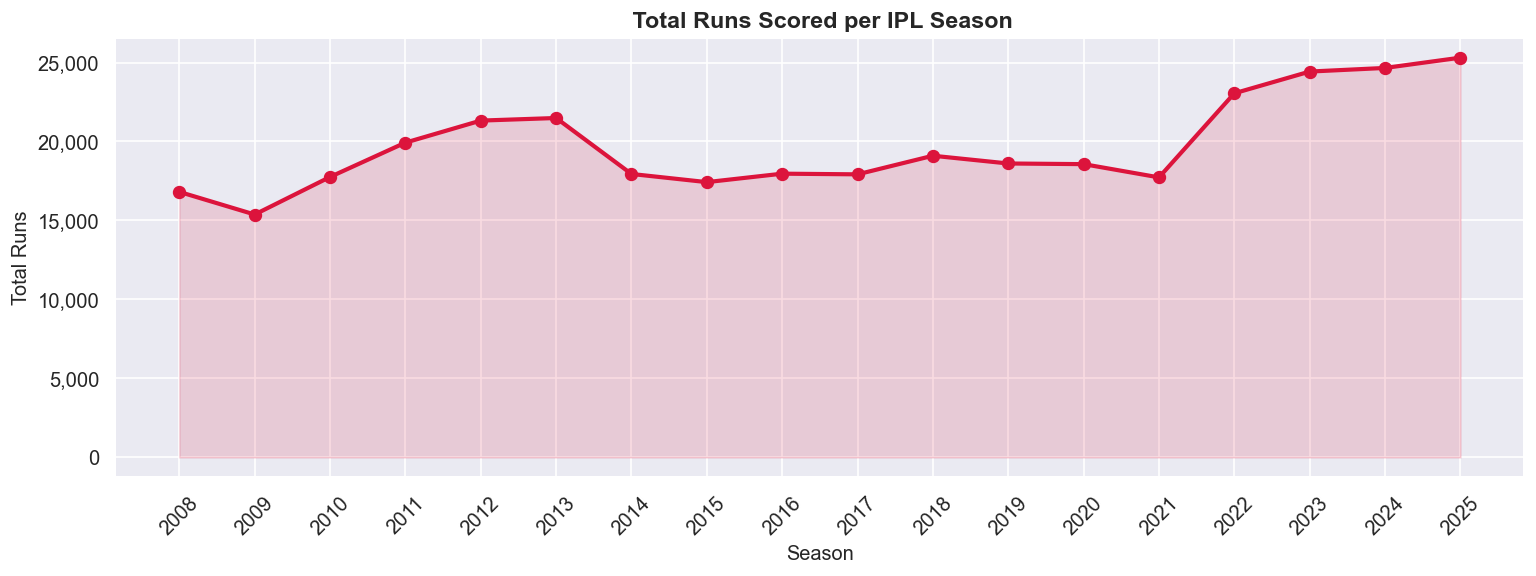

In [15]:

if 'season' in df.columns:
    runs_col = 'runs_batter' if 'runs_batter' in df.columns else 'runs_off_bat'

    season_runs = (
        df.groupby('season')[runs_col]
        .sum()
        .reset_index()
        .rename(columns={runs_col: 'Total Runs'})
    )

    fig, ax = plt.subplots(figsize=(13, 5))
    ax.plot(season_runs['season'], season_runs['Total Runs'],
            marker='o', color='crimson', linewidth=2.5, markersize=7)
    ax.fill_between(season_runs['season'], season_runs['Total Runs'],
                    alpha=0.15, color='crimson')
    ax.set_title(' Total Runs Scored per IPL Season', fontweight='bold')
    ax.set_xlabel('Season')
    ax.set_ylabel('Total Runs')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    plt.xticks(season_runs['season'].astype(int), rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print('  Season column not available.')

In [16]:

toss_cols = {'toss_winner', 'toss_decision', 'winner'}

if toss_cols.issubset(df.columns):
    match_level = df.drop_duplicates(subset='match_id')[['match_id', 'toss_winner', 'toss_decision', 'winner']].copy()
    match_level['toss_won_match'] = match_level['toss_winner'] == match_level['winner']

    toss_win_rate = match_level['toss_won_match'].value_counts(normalize=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Pie chart
    axes[0].pie(toss_win_rate.values,
                labels=['Won Match', 'Lost Match'],
                autopct='%1.1f%%',
                colors=['#2ecc71', '#e74c3c'],
                startangle=140,
                explode=[0.05, 0])
    axes[0].set_title(' Toss Winner → Match Outcome', fontweight='bold')

    # Toss decision distribution
    decision_counts = match_level['toss_decision'].value_counts()
    axes[1].bar(decision_counts.index, decision_counts.values,
                color=['steelblue', 'tomato'])
    axes[1].set_title(' Toss Decision: Field vs Bat', fontweight='bold')
    axes[1].set_xlabel('Decision')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()
else:
    print("  Toss/winner columns not present in this dataset. Skipping toss analysis.")

  Toss/winner columns not present in this dataset. Skipping toss analysis.


In [18]:

if 'winner' in df.columns:
    wins = (
        df.drop_duplicates(subset='match_id')['winner']
        .value_counts()
        .reset_index()
        .rename(columns={'winner': 'Team', 'count': 'Wins'})
        .query("Team != 'Unknown'")
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    palette = sns.color_palette('viridis', len(wins))
    bars = ax.bar(wins['Team'], wins['Wins'], color=palette)
    ax.bar_label(bars, padding=3, fontsize=10, fontweight='bold')
    ax.set_title(' Most Successful IPL Teams by Match Wins', fontweight='bold')
    ax.set_xlabel('Team')
    ax.set_ylabel('Number of Wins')
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
    print(wins.to_string(index=False))
else:
    print('  Winner column not available in this dataset.')

  Winner column not available in this dataset.


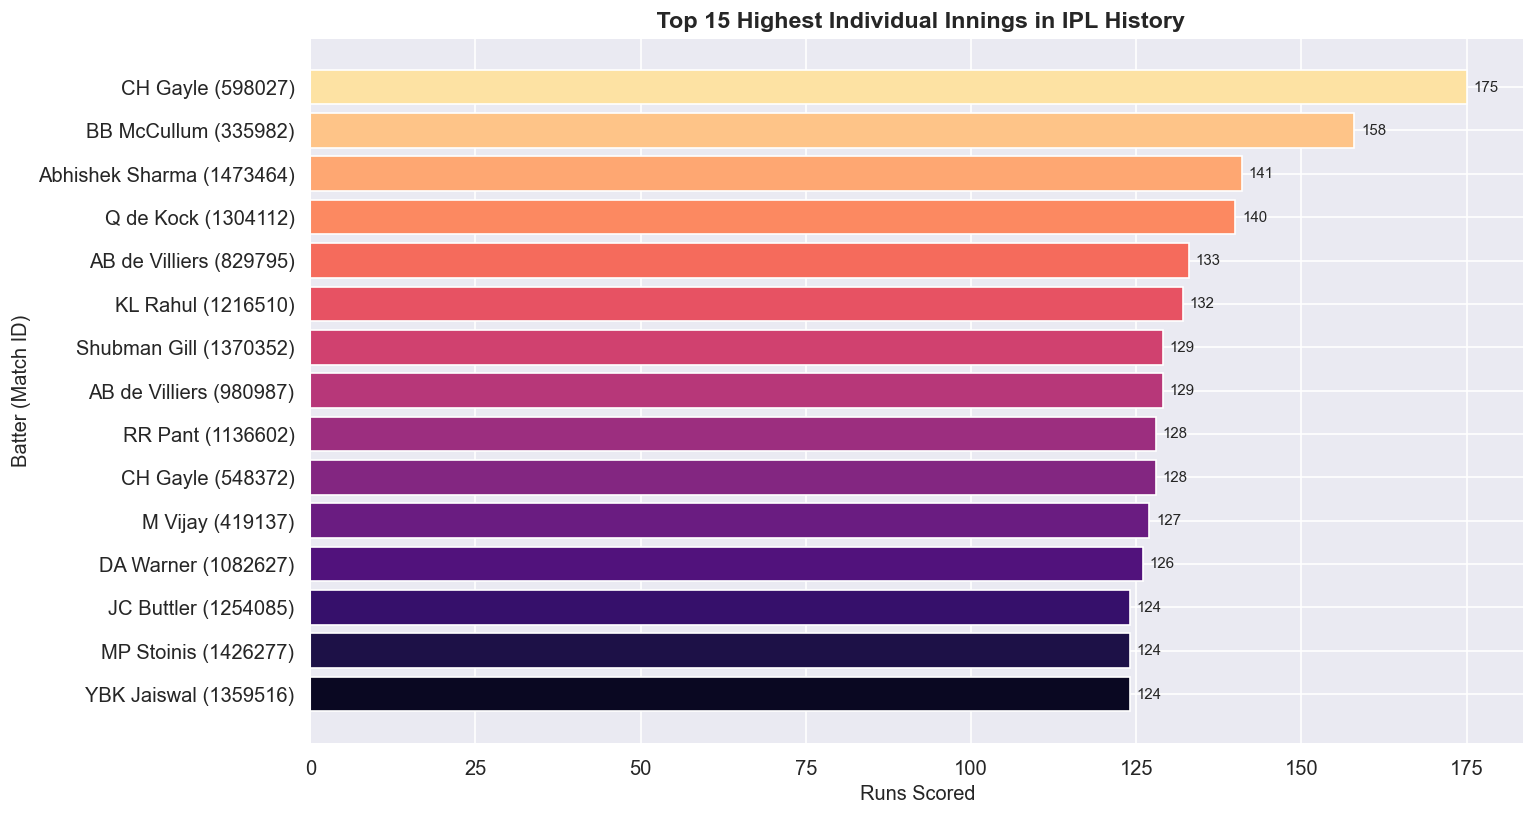

 match_id          batter  Runs       date
   598027        CH Gayle   175 2013-04-23
   335982     BB McCullum   158 2008-04-18
  1473464 Abhishek Sharma   141 2025-04-12
  1304112       Q de Kock   140 2022-05-18
   829795  AB de Villiers   133 2015-05-10
  1216510        KL Rahul   132 2020-09-24
  1370352    Shubman Gill   129 2023-05-26
   980987  AB de Villiers   129 2016-05-14
  1136602         RR Pant   128 2018-05-10
   548372        CH Gayle   128 2012-05-17
   419137         M Vijay   127 2010-04-03
  1082627       DA Warner   126 2017-04-30
  1254085      JC Buttler   124 2021-05-02
  1426277      MP Stoinis   124 2024-04-23
  1359516     YBK Jaiswal   124 2023-04-30


In [20]:

runs_col = 'runs_batter' if 'runs_batter' in df.columns else 'runs_off_bat'

highest_scores = (
    df.groupby(['match_id', 'batter'])[runs_col]
    .sum()
    .reset_index()
    .rename(columns={runs_col: 'Runs'})
    .sort_values('Runs', ascending=False)
    .head(15)
)


if 'date' in df.columns:
    date_map = df.drop_duplicates('match_id')[['match_id', 'date']]
    highest_scores = highest_scores.merge(date_map, on='match_id', how='left')

fig, ax = plt.subplots(figsize=(13, 7))
palette = sns.color_palette('magma', len(highest_scores))[::-1]
bars = ax.barh(highest_scores['batter'] + ' (' + highest_scores['match_id'].astype(str) + ')',
               highest_scores['Runs'], color=palette)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title(' Top 15 Highest Individual Innings in IPL History', fontweight='bold')
ax.set_xlabel('Runs Scored')
ax.set_ylabel('Batter (Match ID)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(highest_scores.to_string(index=False))

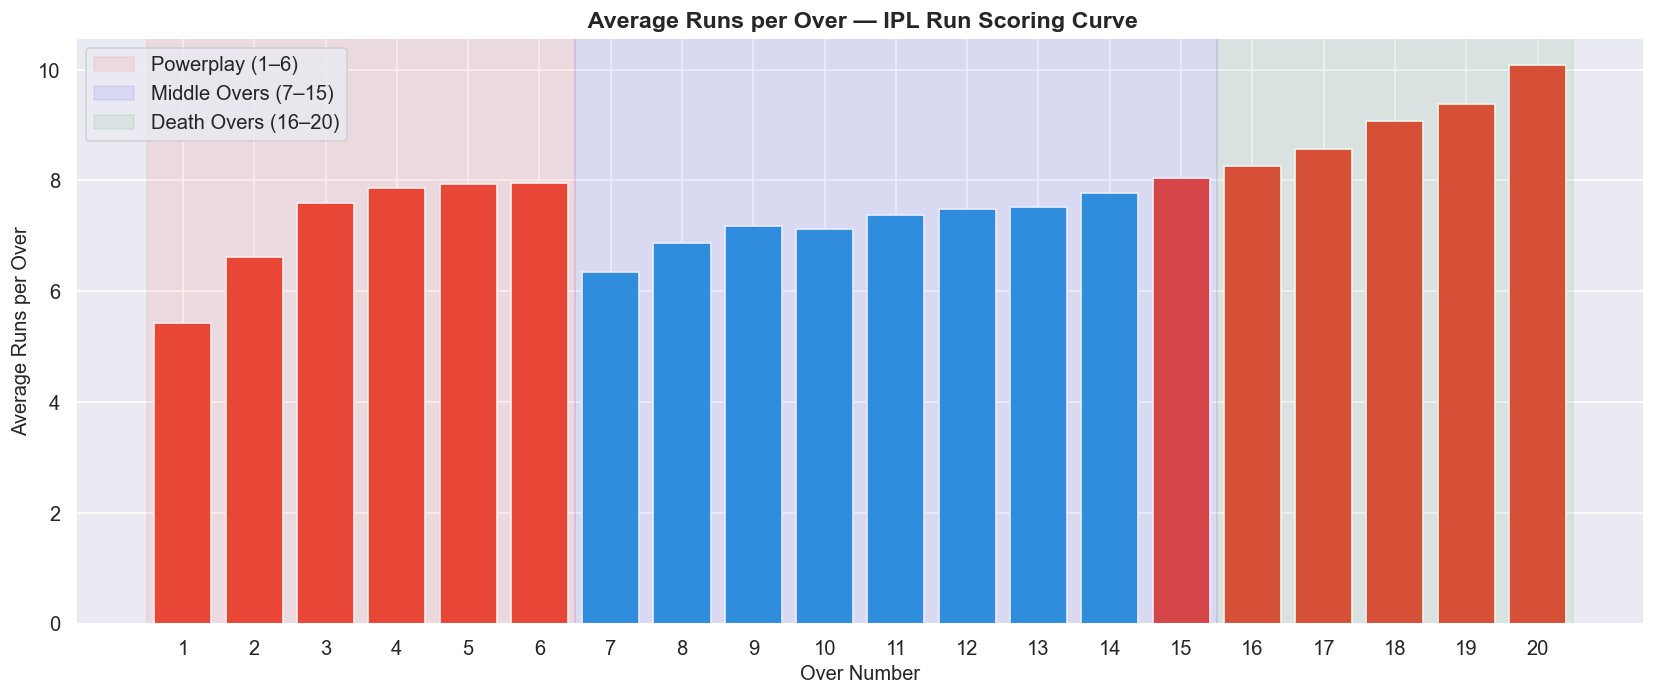

In [25]:

over_col = None
for col in ['over', 'ball', 'over_number']:
    if col in df.columns:
        over_col = col
        break

if over_col:
    runs_col = 'runs_batter' if 'runs_batter' in df.columns else 'runs_off_bat'

    # Normalize over to integer (0-19 → 1-20)
    df['over_int'] = df[over_col].astype(int)
    if df['over_int'].min() == 0:
        df['over_int'] = df['over_int'] + 1  # Convert 0-indexed to 1-indexed

    runs_per_over = (
        df.groupby('over_int')[runs_col]
        .mean()
        .reset_index()
        .rename(columns={'over_int': 'Over', runs_col: 'Avg Runs per Ball'})
    )
    runs_per_over['Avg Runs per Over'] = runs_per_over['Avg Runs per Ball'] * 6

    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ['#e74c3c' if o <= 6 or o >= 15 else '#3498db' for o in runs_per_over['Over']]
    bars = ax.bar(runs_per_over['Over'], runs_per_over['Avg Runs per Over'], color=colors)

    # Phase labels
    ax.axvspan(0.5, 6.5, alpha=0.07, color='red', label='Powerplay (1–6)')
    ax.axvspan(6.5, 15.5, alpha=0.07, color='blue', label='Middle Overs (7–15)')
    ax.axvspan(15.5, 20.5, alpha=0.07, color='green', label='Death Overs (16–20)')

    ax.set_title(' Average Runs per Over — IPL Run Scoring Curve', fontweight='bold')
    ax.set_xlabel('Over Number')
    ax.set_ylabel('Average Runs per Over')
    ax.set_xticks(range(1, 21))
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(' Over column not found in dataset.')